In [ ]:
!pip install -q segmentation-models-pytorch albumentations opencv-python-headless matplotlib pandas numpy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.4 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

import torch
import segmentation_models_pytorch as smp

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [ ]:
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_IMAGE_SIZE = 256   # U-Net++ input size
FINAL_SIZE = 224         # final saved classifier image size
PADDING_RATIO = 0.08
MIN_MASK_AREA_RATIO = 0.01
MASK_THRESHOLD = 0.5

print("DEVICE:", DEVICE)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

DEVICE: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

RAW_DATA_DIR = "/content/drive/MyDrive/TongueImagediabetes/data/tongue-image data"
DIABETES_DIR = os.path.join(RAW_DATA_DIR, "diabetes")
NONDIABETES_DIR = os.path.join(RAW_DATA_DIR, "nondiabetes")

MODEL_PATH = "/content/drive/MyDrive/TongueImagediabetes/seg_models/best_unetplusplus_efficientnetb0.pth"

OUTPUT_BASE_DIR = "/content/drive/MyDrive/TongueImagediabetes/data/processed_segmented_wb"
OUTPUT_DIABETES_DIR = os.path.join(OUTPUT_BASE_DIR, "diabetes")
OUTPUT_NONDIABETES_DIR = os.path.join(OUTPUT_BASE_DIR, "nondiabetes")

os.makedirs(OUTPUT_DIABETES_DIR, exist_ok=True)
os.makedirs(OUTPUT_NONDIABETES_DIR, exist_ok=True)

print("DIABETES_DIR          :", DIABETES_DIR)
print("NONDIABETES_DIR       :", NONDIABETES_DIR)
print("MODEL_PATH            :", MODEL_PATH)
print("OUTPUT_DIABETES_DIR   :", OUTPUT_DIABETES_DIR)
print("OUTPUT_NONDIABETES_DIR:", OUTPUT_NONDIABETES_DIR)

Mounted at /content/drive
DIABETES_DIR          : /content/drive/MyDrive/TongueImagediabetes/data/tongue-image data/diabetes
NONDIABETES_DIR       : /content/drive/MyDrive/TongueImagediabetes/data/tongue-image data/nondiabetes
MODEL_PATH            : /content/drive/MyDrive/TongueImagediabetes/seg_models/best_unetplusplus_efficientnetb0.pth
OUTPUT_DIABETES_DIR   : /content/drive/MyDrive/TongueImagediabetes/data/processed_segmented_wb/diabetes
OUTPUT_NONDIABETES_DIR: /content/drive/MyDrive/TongueImagediabetes/data/processed_segmented_wb/nondiabetes


In [ ]:
def build_dataframe_from_class_folders(diabetes_dir, nondiabetes_dir):
    rows = []

    diabetes_paths = sorted(Path(diabetes_dir).glob("*.*"))
    for img_path in diabetes_paths:
        rows.append({
            "image_name": img_path.name,
            "image_path": str(img_path),
            "label_name": "diabetes",
            "save_dir": OUTPUT_DIABETES_DIR
        })

    nondiabetes_paths = sorted(Path(nondiabetes_dir).glob("*.*"))
    for img_path in nondiabetes_paths:
        rows.append({
            "image_name": img_path.name,
            "image_path": str(img_path),
            "label_name": "nondiabetes",
            "save_dir": OUTPUT_NONDIABETES_DIR
        })

    return pd.DataFrame(rows)

df = build_dataframe_from_class_folders(DIABETES_DIR, NONDIABETES_DIR)

print("Total images:", len(df))
print(df["label_name"].value_counts())
df.head()

Total images: 957
label_name
nondiabetes    519
diabetes       438
Name: count, dtype: int64


,image_name,image_path,label_name,save_dir
0,0061042d-5658-44bd-b9c3-a18ad7763841 - Talal n...,/content/drive/MyDrive/TongueImagediabetes/dat...,diabetes,/content/drive/MyDrive/TongueImagediabetes/dat...
1,16E6BE8C-B20A-4051-9F94-17B8A042F042 - Talal N...,/content/drive/MyDrive/TongueImagediabetes/dat...,diabetes,/content/drive/MyDrive/TongueImagediabetes/dat...
2,1cd36c45-0842-491a-bab0-0951b26443bc - Talal n...,/content/drive/MyDrive/TongueImagediabetes/dat...,diabetes,/content/drive/MyDrive/TongueImagediabetes/dat...
3,20251117_232905 - Ribqa Raza Malik.jpg,/content/drive/MyDrive/TongueImagediabetes/dat...,diabetes,/content/drive/MyDrive/TongueImagediabetes/dat...
4,39ba90a2-fac4-4bb3-bf41-6df2088c4c99 - Talal n...,/content/drive/MyDrive/TongueImagediabetes/dat...,diabetes,/content/drive/MyDrive/TongueImagediabetes/dat...


In [ ]:
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b0",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None
)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print("U-Net++ model loaded successfully.")

U-Net++ model loaded successfully.


In [ ]:
inference_transform = A.Compose([
    A.Resize(MODEL_IMAGE_SIZE, MODEL_IMAGE_SIZE),
    A.Normalize(),
    ToTensorV2()
])

In [ ]:
def read_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

In [ ]:
def predict_mask(image_rgb, model, transform, device, threshold=0.5):
    original_h, original_w = image_rgb.shape[:2]

    transformed = transform(image=image_rgb)
    image_tensor = transformed["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.sigmoid(logits)
        pred_mask = (probs > threshold).float()

    pred_mask = pred_mask.squeeze().cpu().numpy().astype(np.uint8)

    pred_mask = cv2.resize(
        pred_mask,
        (original_w, original_h),
        interpolation=cv2.INTER_NEAREST
    )

    return pred_mask

In [ ]:
def keep_largest_component(mask):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    if num_labels <= 1:
        return mask

    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    largest_mask = (labels == largest_label).astype(np.uint8)

    return largest_mask


def fill_holes(mask):
    mask_255 = (mask * 255).astype(np.uint8)
    h, w = mask_255.shape

    flood = mask_255.copy()
    flood_mask = np.zeros((h + 2, w + 2), dtype=np.uint8)

    cv2.floodFill(flood, flood_mask, (0, 0), 255)

    flood_inv = cv2.bitwise_not(flood)
    filled = cv2.bitwise_or(mask_255, flood_inv)

    return (filled > 127).astype(np.uint8)


def clean_mask(mask):
    mask = keep_largest_component(mask)
    mask = fill_holes(mask)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    return (mask > 0).astype(np.uint8)


def is_mask_valid(mask, min_area_ratio=0.01):
    area = mask.sum()
    total_pixels = mask.shape[0] * mask.shape[1]
    area_ratio = area / total_pixels
    return area_ratio >= min_area_ratio

In [ ]:
def get_bbox_from_mask(mask):
    ys, xs = np.where(mask > 0)

    if len(xs) == 0 or len(ys) == 0:
        return None

    x_min = xs.min()
    x_max = xs.max()
    y_min = ys.min()
    y_max = ys.max()

    return x_min, y_min, x_max, y_max


def crop_with_padding(image, mask, padding_ratio=0.08):
    bbox = get_bbox_from_mask(mask)

    if bbox is None:
        return None, None

    x_min, y_min, x_max, y_max = bbox
    h, w = image.shape[:2]

    box_w = x_max - x_min + 1
    box_h = y_max - y_min + 1

    pad_x = int(box_w * padding_ratio)
    pad_y = int(box_h * padding_ratio)

    x_min = max(0, x_min - pad_x)
    y_min = max(0, y_min - pad_y)
    x_max = min(w - 1, x_max + pad_x)
    y_max = min(h - 1, y_max + pad_y)

    cropped_image = image[y_min:y_max + 1, x_min:x_max + 1]
    cropped_mask = mask[y_min:y_max + 1, x_min:x_max + 1]

    return cropped_image, cropped_mask


def apply_mask(image, mask):
    masked_image = image.copy()
    masked_image[mask == 0] = 0
    return masked_image


def resize_and_pad(image, target_size=224):
    h, w = image.shape[:2]

    scale = target_size / max(h, w)

    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    resized_image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    pad_w = target_size - new_w
    pad_h = target_size - new_h

    left = pad_w // 2
    right = pad_w - left
    top = pad_h // 2
    bottom = pad_h - top

    padded_image = cv2.copyMakeBorder(
        resized_image,
        top, bottom, left, right,
        borderType=cv2.BORDER_CONSTANT,
        value=(0, 0, 0)
    )

    return padded_image


def save_rgb_image(save_path, image_rgb):
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, image_bgr)


def gray_world_white_balance(image_rgb, strength=0.4):
    image = image_rgb.astype(np.float32)

    non_black = np.any(image > 0, axis=-1)
    if not np.any(non_black):
        return image_rgb

    r = image[:, :, 0]
    g = image[:, :, 1]
    b = image[:, :, 2]

    r_mean = np.mean(r[non_black])
    g_mean = np.mean(g[non_black])
    b_mean = np.mean(b[non_black])

    gray_mean = (r_mean + g_mean + b_mean) / 3.0

    r_scale = gray_mean / (r_mean + 1e-8)
    g_scale = gray_mean / (g_mean + 1e-8)
    b_scale = gray_mean / (b_mean + 1e-8)

    # apply only partial correction
    r = r * (1 + strength * (r_scale - 1))
    g = g * (1 + strength * (g_scale - 1))
    b = b * (1 + strength * (b_scale - 1))

    balanced = np.stack([r, g, b], axis=-1)
    balanced = np.clip(balanced, 0, 255).astype(np.uint8)

    balanced[~non_black] = 0

    return balanced

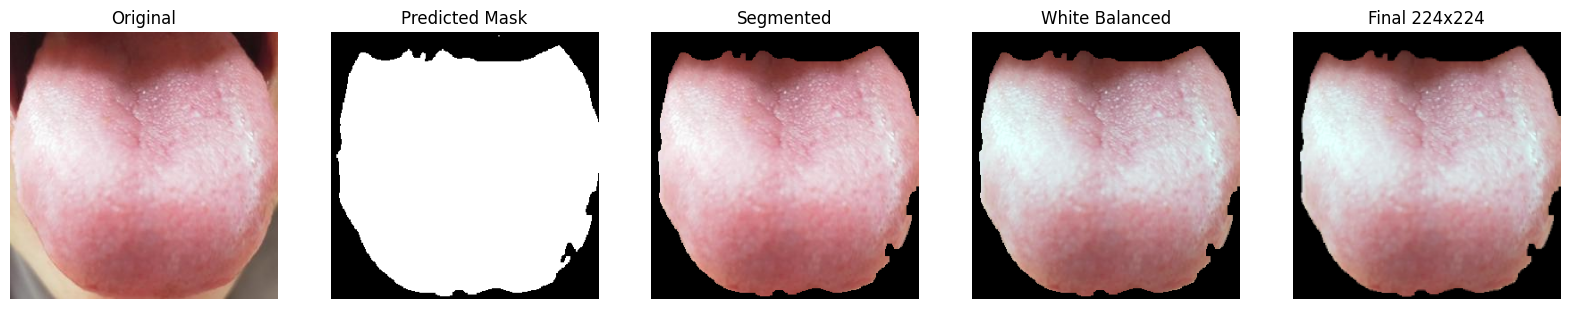

Mask valid: True


In [ ]:
sample = df.sample(1, random_state=SEED).iloc[0]

image = read_image(sample["image_path"])

pred_mask = predict_mask(
    image_rgb=image,
    model=model,
    transform=inference_transform,
    device=DEVICE,
    threshold=MASK_THRESHOLD
)

cleaned_mask = clean_mask(pred_mask)

cropped_image, cropped_mask = crop_with_padding(
    image,
    cleaned_mask,
    padding_ratio=PADDING_RATIO
)

segmented_image = apply_mask(cropped_image, cropped_mask)

# NEW STEP: white balance
wb_image = gray_world_white_balance(segmented_image)

final_image = resize_and_pad(wb_image, target_size=FINAL_SIZE)

plt.figure(figsize=(20,4))

plt.subplot(1,5,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.subplot(1,5,3)
plt.imshow(segmented_image)
plt.title("Segmented")
plt.axis("off")

plt.subplot(1,5,4)
plt.imshow(wb_image)
plt.title("White Balanced")
plt.axis("off")

plt.subplot(1,5,5)
plt.imshow(final_image)
plt.title("Final 224x224")
plt.axis("off")

plt.show()

print("Mask valid:", is_mask_valid(cleaned_mask, MIN_MASK_AREA_RATIO))

In [ ]:
def process_one_sample(image_path, save_path,
                       model,
                       transform,
                       device,
                       padding_ratio=PADDING_RATIO,
                       final_size=FINAL_SIZE,
                       min_mask_area_ratio=MIN_MASK_AREA_RATIO,
                       threshold=MASK_THRESHOLD):

    image = read_image(image_path)

    pred_mask = predict_mask(
        image_rgb=image,
        model=model,
        transform=transform,
        device=device,
        threshold=threshold
    )

    cleaned_mask = clean_mask(pred_mask)

    if not is_mask_valid(cleaned_mask, min_mask_area_ratio):
        return False, "invalid_mask"

    cropped_image, cropped_mask = crop_with_padding(
        image,
        cleaned_mask,
        padding_ratio=padding_ratio
    )

    if cropped_image is None or cropped_mask is None:
        return False, "empty_crop"

    segmented_image = apply_mask(cropped_image, cropped_mask)

    # NEW STEP: white balance
    wb_image = gray_world_white_balance(segmented_image)

    final_image = resize_and_pad(wb_image, target_size=final_size)

    save_rgb_image(save_path, final_image)

    return True, "ok"

In [ ]:
results = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    image_name = Path(row["image_name"]).stem
    save_path = os.path.join(row["save_dir"], image_name + ".png")

    success, reason = process_one_sample(
        image_path=row["image_path"],
        save_path=save_path,
        model=model,
        transform=inference_transform,
        device=DEVICE
    )

    results.append({
        "image_name": row["image_name"],
        "label": row["label_name"],
        "success": success,
        "reason": reason
    })

100%|██████████| 957/957 [06:56<00:00,  2.30it/s]


Total saved images: 954


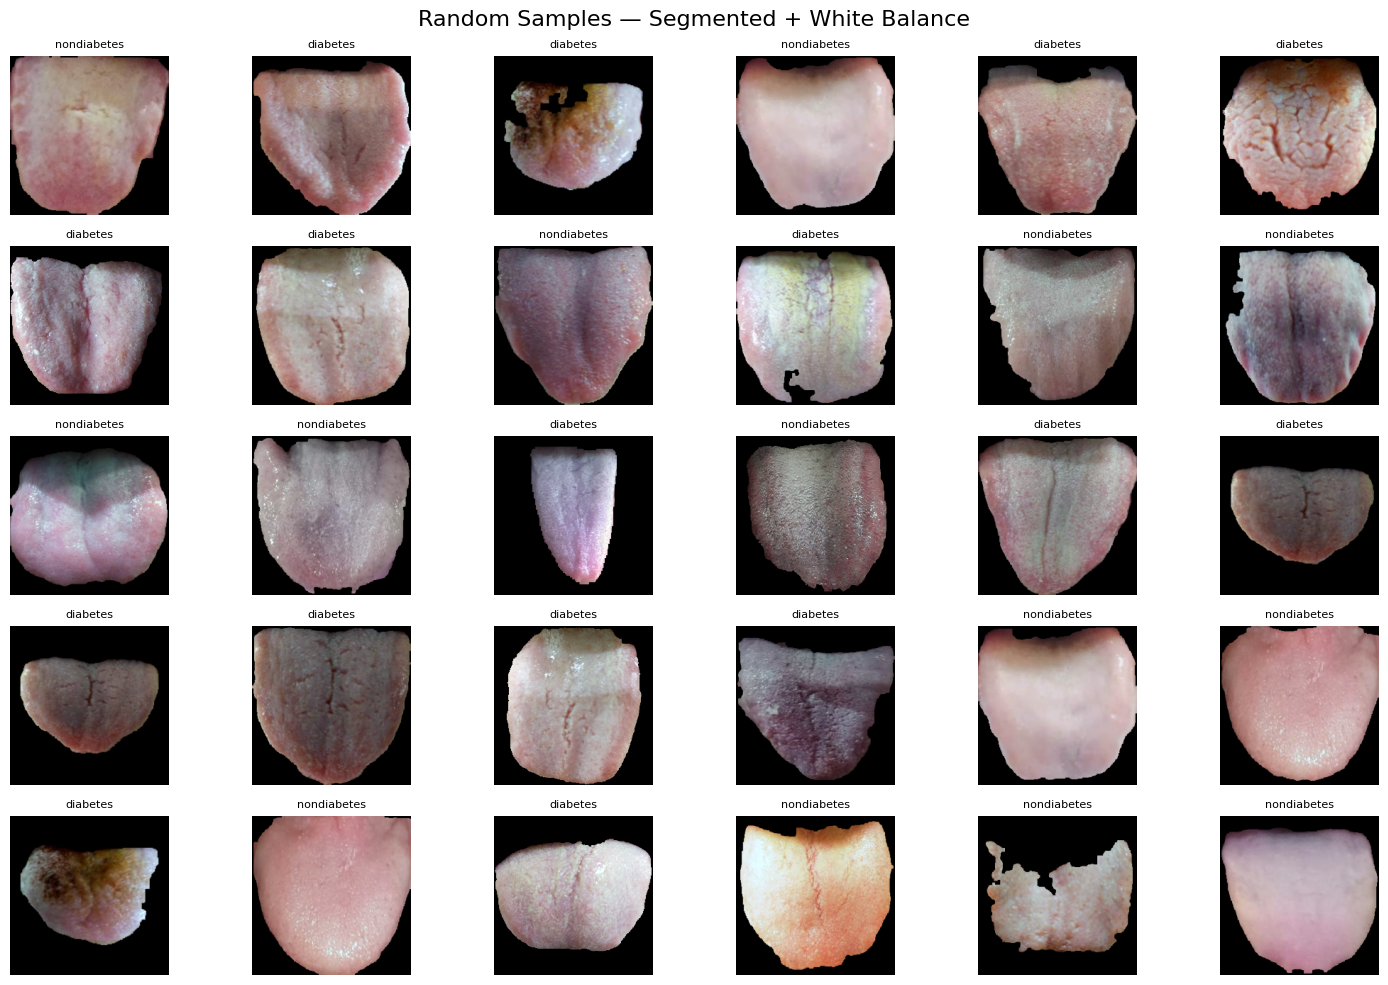

In [ ]:
saved_files = list(Path(OUTPUT_BASE_DIR).rglob("*.png"))

print("Total saved images:", len(saved_files))

sample_files = random.sample(saved_files, min(30, len(saved_files)))

plt.figure(figsize=(15, 10))

for i, img_path in enumerate(sample_files):
    img = read_image(str(img_path))

    plt.subplot(5, 6, i + 1)
    plt.imshow(img)
    plt.title(img_path.parent.name, fontsize=8)
    plt.axis("off")

plt.suptitle("Random Samples — Segmented + White Balance", fontsize=16)
plt.tight_layout()
plt.show()